# Reinforcement Learning - Minimalistic Example:

Imagine a casino with some classic slot machines (one-arm bandits) - you can consider them as classic Laplacian probability devices: The will produce a random output, but they may have different mean values (at least for the sake of this exercise - see ``true means``: one of them will deliver the highest mean and therefore best result, ergo the highest reward).  These machines would be the **environment**.

A **model/agent** is now set to do pulls at the machines. The **actions** in this case would be the different machines which can be used by the agent.

In order to train a model to learn from **accumulated experience**, a **reward** is given based on the mean of the machine used. This way, the probability of using the best machine will be improving over the training epochs. The algorithm learns only from interaction — no labels, no model of the world. The true means are unknown to the agent, so the pulls will be random at first but gradually improve as the probability is adapted due to the reward.

Note that in this case, the reward is immediate and the state of the environment is not changed (Laplacian probability!). Therefore, the state and future rewards (discounts) do not have to be considered here.

Find below the code for this reduced example and see how you could implement RL in Pytorch.

1) Import dependencies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical # this is what actually makes this a policy gradient, instead of classic supervised learning
import numpy as np

2. Define the environment

Note that on the reward, some Gaussian noise is added to capture variance and uncertainty. 

In [ ]:
# Bandit environment: The basic description of a random machine with a certain mean
class Bandit:
    def __init__(self, means):
        self.means = means

    def pull(self, action):
        # Gaussian reward from pulling a chosen arm  => some random noise + the means since we need to push the machines to the means
        return np.random.randn() + self.means[action]

3) Define the policy

Policy = how the agent decides on an action. In this case, only an array of trainable numbers for each action. No network, no states -> simplest possible policy.

These trainable numbers will be converted to actual probabilities using the softmax function (ensures that all probabilities are >= 0 and the total sum is 1). This makes the gradient well-behaved.

In [ ]:

# Policy
class Policy(nn.Module):
    def __init__(self, num_arms):
        super().__init__()
        # One learnable logit per arm
        self.logits = nn.Parameter(torch.zeros(num_arms))

    def forward(self):
        return torch.softmax(self.logits, dim=0) # softmax ensures like ReLu everything higher than 0, smooth ReLU function

4) Setup

The number of slot machines and which one is the best. The agent does not know the latter!

In [ ]:
# Setup
num_arms = 5
true_means = [0.2, 1.0, -0.3, 0.5, 0.0]  # second arm (index = 1) is best
env = Bandit(true_means)

policy = Policy(num_arms) # probability array
optimizer = optim.Adam(policy.parameters(), lr=0.1)


# Define baseline (variance reduction) - very important!
# Basically helps to determine: "Was this reward better than usual?"

baseline = 0.0 # instead dealing with absolute numbers
alpha = 0.9  # baseline smoothing


5) Training

Note: 
- Sampling is used instead of argmax - this means that the agent needs to explore instead of just going for the max (exploit).

- The probability loss will be updated based on the ``advantage`` (better or worse than baseline), not the reward directly!

- ``log_prob(action)`` measures how likely the policy made this action. We want to maximise the reward, hence the negative sign, as pytorch normally wants to minimise loss! (bigger reward -> higher probability -> lower loss).

In [5]:
# Training

for step in range(1000):
    probs = policy()
    dist = Categorical(probs)
    action = dist.sample()

    reward = env.pull(action.item())

    # Update baseline (moving average)
    baseline = alpha * baseline + (1 - alpha) * reward
    advantage = reward - baseline

    loss = -dist.log_prob(action) * advantage

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Logging the training progress
    if step % 100 == 0:
        print(f"Step {step:4d} | "
              f"Reward: {reward:+.2f} | "
              f"Probs: {probs.detach().numpy()}")

Step    0 | Reward: -1.36 | Probs: [0.2 0.2 0.2 0.2 0.2]
Step  100 | Reward: +0.21 | Probs: [0.01592924 0.92979133 0.0096938  0.03340934 0.01117632]
Step  200 | Reward: +0.61 | Probs: [0.00411479 0.9775767  0.00188514 0.01155953 0.00486389]
Step  300 | Reward: +1.51 | Probs: [8.9873117e-04 9.9372816e-01 3.9050481e-04 3.0932110e-03 1.8893755e-03]
Step  400 | Reward: +2.80 | Probs: [9.1900816e-04 9.9347454e-01 3.9869791e-04 3.2715430e-03 1.9362688e-03]
Step  500 | Reward: +0.99 | Probs: [1.0857926e-03 9.9113327e-01 4.7082774e-04 5.0131758e-03 2.2968359e-03]
Step  600 | Reward: +0.26 | Probs: [1.0772084e-03 9.9123693e-01 4.6731150e-04 4.9486253e-03 2.2699842e-03]
Step  700 | Reward: +1.80 | Probs: [6.4017461e-04 9.9321741e-01 3.7567064e-04 3.9515123e-03 1.8152497e-03]
Step  800 | Reward: +2.25 | Probs: [3.4789031e-04 9.9761462e-01 2.0412699e-04 8.4280968e-04 9.9068636e-04]
Step  900 | Reward: +0.39 | Probs: [3.4622604e-04 9.9763095e-01 2.0317362e-04 8.3733350e-04 9.8233216e-04]


### Tasks and follow-up:
1) The baseline was added for stability. See what happens when you don't use it, but rather just the reward by setting ;;; hint => will make it really unstable
```
advantage = reward
loss = -dist.log_prob(action) * advantage
```
2) Explore an epsilon-greedy approach instead of the policy gradient by using the snippet below. For this, you will make use of Q and N functions (value functions). How is the result affected by this?

In [6]:
num_arms = 5
true_means = [0.2, 1.0, -0.3, 0.5, 0.0]
env = Bandit(true_means)

Q = torch.zeros(num_arms)
N = torch.zeros(num_arms)

epsilon = 0.1
lr = 0.1

for step in range(1000):

    # ε-greedy action selection
    if np.random.rand() < epsilon:
        action = np.random.randint(num_arms)
    else:
        action = torch.argmax(Q).item()

    reward = env.pull(action)

    # Incremental Q update
    N[action] += 1
    Q[action] += lr * (reward - Q[action])

    if step % 100 == 0:
        print(f"Step {step:4d} | Q-values: {Q.numpy()}")


Step    0 | Q-values: [0.         0.05975179 0.         0.         0.        ]
Step  100 | Q-values: [-0.06138799  1.1242049   0.          0.19081812 -0.07296422]
Step  200 | Q-values: [-0.01703576  1.2071413   0.09755485  0.2098302  -0.03643399]
Step  300 | Q-values: [-0.11088464  0.87690693 -0.10087749  0.1557152  -0.09190046]
Step  400 | Q-values: [ 0.15662009  0.8621794  -0.28299022  0.11488946  0.05732983]
Step  500 | Q-values: [ 0.09223806  1.0451704  -0.495644    0.26710078  0.01332942]
Step  600 | Q-values: [ 0.09223806  1.0159019  -0.45552686  0.19635266  0.01332942]
Step  700 | Q-values: [ 0.16046941  0.90561414 -0.35311633  0.10048948  0.28655577]
Step  800 | Q-values: [ 0.14450206  1.0547328  -0.2520209   0.2952808   0.19842432]
Step  900 | Q-values: [-0.06962378  0.8234664  -0.3473702   0.22870018  0.14885792]


3) Log cumulative regret over time

Regret is defined as the difference between highest possible reward and the reward actually achieved. Learning will minimise the growth of the regret.

Use the snippet below to plot a regret curve:


In [7]:
# Compute optimal mean
optimal_mean = max(true_means)
cumulative_regret = 0.0
regret_log = []

In [8]:
# Adapted training loop:

for step in range(1000):
    probs = policy()
    dist = Categorical(probs)
    action = dist.sample()

    reward = env.pull(action.item())

    # regret added to the loop
    regret = optimal_mean - reward
    cumulative_regret += regret
    regret_log.append(cumulative_regret)


    # Update baseline (moving average)
    baseline = alpha * baseline + (1 - alpha) * reward
    advantage = reward - baseline

    loss = -dist.log_prob(action) * advantage

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Logging the training progress
    if step % 100 == 0:
        print(f"Step {step:4d} | "
              f"Reward: {reward:+.2f} | "
              f"Probs: {probs.detach().numpy()} | "
              f"Regret: {cumulative_regret:.2f}")

Step    0 | Reward: +1.15 | Probs: [3.4788178e-04 9.9761486e-01 2.0412024e-04 8.4238796e-04 9.9088694e-04] | Regret: -0.15
Step  100 | Reward: +1.21 | Probs: [3.4477483e-04 9.9764532e-01 2.0234392e-04 8.3290623e-04 9.7476947e-04] | Regret: -14.88
Step  200 | Reward: -1.25 | Probs: [3.4736848e-04 9.9761981e-01 2.0382692e-04 8.4081781e-04 9.8814431e-04] | Regret: -14.91
Step  300 | Reward: +1.93 | Probs: [3.4895766e-04 9.9760431e-01 2.0473568e-04 8.4567326e-04 9.9636731e-04] | Regret: -10.63
Step  400 | Reward: +2.29 | Probs: [3.1251198e-04 9.9809617e-01 1.8337114e-04 7.5654412e-04 6.5141008e-04] | Regret: -0.48
Step  500 | Reward: -0.26 | Probs: [3.1293280e-04 9.9809331e-01 1.8360946e-04 7.5793394e-04 6.5222685e-04] | Regret: 15.49
Step  600 | Reward: +2.06 | Probs: [3.1171882e-04 9.9810314e-01 1.8291689e-04 7.5414451e-04 6.4814737e-04] | Regret: 35.15
Step  700 | Reward: +2.40 | Probs: [3.1105173e-04 9.9810851e-01 1.8253659e-04 7.5206108e-04 6.4589345e-04] | Regret: 26.14
Step  800 | R

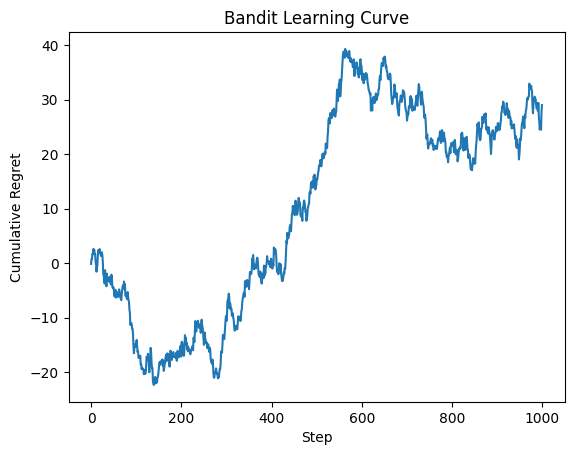

In [9]:
import matplotlib.pyplot as plt

plt.plot(regret_log)
plt.xlabel("Step")
plt.ylabel("Cumulative Regret")
plt.title("Bandit Learning Curve")
plt.show()

Note for the graph: What does good learning look like?
- Random: Linear plot
- Learning: Sub-linear
- Optimal: Flat-ish
